In [ ]:
# import libraries
import pandas as pd

In [5]:
#read data using read_csv : courses_sales.csv
df = pd.read_csv("courses_sales.csv")

In [6]:
# show first 5 rows
df.head()

,Invoice_ID,City,Course_Name,Course_Type,Level,Price,Discount,Final_Total,Enrollment_Date,Rating
0,INV-10001,Mecca,Laravel & PHP,Recorded Subscription,Advanced,532,266,266,2023-03-17,4.1
1,INV-10002,Jeddah,Laravel & PHP,Recorded Subscription,Beginner,289,0,289,2023-09-18,4.5
2,INV-10003,Dammam,UI/UX Design,Recorded Subscription,Intermediate,474,94,380,2024-02-19,4.4
3,INV-10004,Khobar,UI/UX Design,Recorded Subscription,Beginner,265,0,265,2023-04-10,4.7
4,INV-10005,Mecca,React & Next.js,Recorded Subscription,Beginner,228,45,183,2023-03-22,4.6


In [7]:
# (row , column)
df.shape

(5000, 10)

In [8]:
# general information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Invoice_ID       5000 non-null   object 
 1   City             5000 non-null   object 
 2   Course_Name      5000 non-null   object 
 3   Course_Type      5000 non-null   object 
 4   Level            5000 non-null   object 
 5   Price            5000 non-null   int64  
 6   Discount         5000 non-null   int64  
 7   Final_Total      5000 non-null   int64  
 8   Enrollment_Date  5000 non-null   object 
 9   Rating           4950 non-null   float64
dtypes: float64(1), int64(3), object(6)
memory usage: 390.8+ KB


In [30]:
# الجدول فيه 5000 سطر و 10 أعمد.
#لما شغّلت الكود لاحظت إن كل الأعمدة فيها 5000 قيمة ما عدا عمود الريتينق — فيه بس 4950.
#يعني 50 شخص ما حطوا تقييم.
#50 من أصل 5000 = 1% بس — وهذا رقم صغير جداً، يعني البيانات شبه كاملة ونظيفة.
#من اصل 5000 ناقصة 50 يعني 1 ف المية والبيانات شبه كاملة ونظيفة بس فيها هذا النقص 

In [10]:
# simple statistical summary ( numeric columns only)
df.describe()

,Price,Discount,Final_Total,Rating
count,5000.000000,5000.000000,5000.000000,4950.000000
mean,716.655200,60.263400,656.391800,4.381111
std,718.728041,76.641777,736.090716,0.326131
min,200.000000,0.000000,100.000000,3.800000
25%,293.000000,0.000000,231.000000,4.100000
50%,404.500000,43.000000,323.000000,4.400000
75%,599.250000,98.000000,528.250000,4.700000
max,2999.000000,325.000000,2999.000000,5.000000


In [11]:
# show last 5 rows
df.tail()

,Invoice_ID,City,Course_Name,Course_Type,Level,Price,Discount,Final_Total,Enrollment_Date,Rating
4995,INV-14996,Jeddah,Data Analysis,Live Bootcamp,Beginner,1681,168,1513,2023-10-10,4.9
4996,INV-14997,Khobar,UI/UX Design,Recorded Subscription,Advanced,558,111,447,2023-01-05,4.2
4997,INV-14998,Mecca,React & Next.js,Recorded Subscription,Beginner,244,48,196,2023-04-30,4.1
4998,INV-14999,Mecca,Laravel & PHP,Live Bootcamp,Beginner,1559,0,1559,2024-03-01,4.7
4999,INV-15000,Medina,Python Basics,Recorded Subscription,Beginner,280,140,140,2023-07-17,4.7


In [12]:
# count distinct values in Level column
level_counts = df["Level"].value_counts()
level_counts

Level
Beginner        2548
Intermediate    1478
Advanced         974
Name: count, dtype: int64

In [ ]:
#الاستنتاج هنا ان السوق فيه طلب كبير على الكورسات للمبتدئين اكثر من غيرها يعني اكثر من نص المتدربين مبتدئين
#Beginner: 2548
#Intermediate: 1478
#Advanced: 974

In [13]:
# group the Course Name based on City 
df.groupby("City")["Course_Name"].count().sort_values(ascending=False)

City
Riyadh    937
Jeddah    860
Dammam    775
Medina    634
Khobar    626
Mecca     600
Tabuk     568
Name: Course_Name, dtype: int64

In [14]:
# group Levels based on average Price
df.groupby("Level")["Price"].mean()

Level
Advanced        1018.065708
Beginner         555.673469
Intermediate     795.550744
Name: Price, dtype: float64

In [15]:
#الأرقام تصاعدية كلما كان الكورس أصعب كلما ارتفع سعره.
#وفي نفس الوقت الرياض عندها 937 عملية بيع يعني هي السوق الأكبر
# Beginner متوسط الاسعار لكل كورس: 555
# Intermediate: 795
# Advanced: 1018

In [16]:
# Filter Rating >= 4.7 and show first 5 rows
df[df["Rating"]>= 4.7].head()

,Invoice_ID,City,Course_Name,Course_Type,Level,Price,Discount,Final_Total,Enrollment_Date,Rating
3,INV-10004,Khobar,UI/UX Design,Recorded Subscription,Beginner,265,0,265,2023-04-10,4.7
7,INV-10008,Tabuk,Data Analysis,Recorded Subscription,Beginner,211,42,169,2023-10-12,4.7
8,INV-10009,Riyadh,Flutter Development,Recorded Subscription,Intermediate,397,0,397,2023-04-01,4.8
12,INV-10013,Riyadh,Python Basics,Live Bootcamp,Beginner,1559,0,1559,2023-04-08,4.9
20,INV-10021,Khobar,UI/UX Design,Recorded Subscription,Intermediate,384,0,384,2023-03-25,4.7


<Axes: xlabel='Course_Type'>

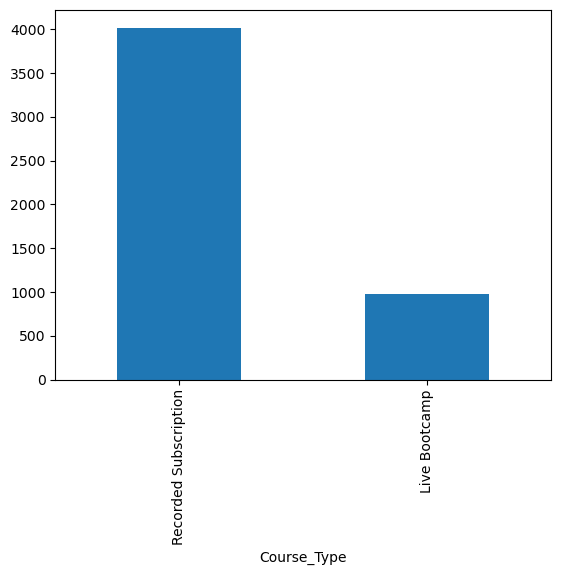

In [24]:
# Count the number of sales for each Course_Type and plot a bar chart
df["Course_Type"].value_counts().plot(kind="bar")

In [26]:
#Recorded Subscription كان هو الاكثر في اشتراكات الكورسات

In [27]:
# Filter sales that happened in Riyadh only and show first 5 rows
df[df["City"]=="Riyadh"].head()

,Invoice_ID,City,Course_Name,Course_Type,Level,Price,Discount,Final_Total,Enrollment_Date,Rating
5,INV-10006,Riyadh,Flutter Development,Live Bootcamp,Beginner,1542,0,1542,2023-03-12,4.5
8,INV-10009,Riyadh,Flutter Development,Recorded Subscription,Intermediate,397,0,397,2023-04-01,4.8
12,INV-10013,Riyadh,Python Basics,Live Bootcamp,Beginner,1559,0,1559,2023-04-08,4.9
16,INV-10017,Riyadh,Data Analysis,Recorded Subscription,Intermediate,466,0,466,2023-07-19,3.9
23,INV-10024,Riyadh,Python Basics,Recorded Subscription,Intermediate,468,93,375,2024-03-06,4.8


In [19]:
# Filter Level == 'Beginner' AND Course_Type == 'Live Bootcamp' and show first 5 rows
df[(df["Level"]=="Beginner")&(df["Course_Type"]=="Live Bootcamp")].head()

,Invoice_ID,City,Course_Name,Course_Type,Level,Price,Discount,Final_Total,Enrollment_Date,Rating
5,INV-10006,Riyadh,Flutter Development,Live Bootcamp,Beginner,1542,0,1542,2023-03-12,4.5
12,INV-10013,Riyadh,Python Basics,Live Bootcamp,Beginner,1559,0,1559,2023-04-08,4.9
36,INV-10037,Dammam,Data Analysis,Live Bootcamp,Beginner,1879,0,1879,2023-11-02,4.6
52,INV-10053,Jeddah,React & Next.js,Live Bootcamp,Beginner,1985,0,1985,2023-06-13,4.6
53,INV-10054,Jeddah,UI/UX Design,Live Bootcamp,Beginner,1549,0,1549,2023-01-26,4.7


In [20]:
# Filter rows where Rating is missing (NaN) and show first 5 rows
df[df["Rating"].isna()].head()

,Invoice_ID,City,Course_Name,Course_Type,Level,Price,Discount,Final_Total,Enrollment_Date,Rating
56,INV-10057,Riyadh,Flutter Development,Live Bootcamp,Advanced,2852,0,2852,2024-03-17,NaN
312,INV-10313,Tabuk,UI/UX Design,Recorded Subscription,Advanced,585,292,293,2023-07-26,NaN
474,INV-10475,Jeddah,Flutter Development,Recorded Subscription,Advanced,523,0,523,2023-04-17,NaN
514,INV-10515,Riyadh,UI/UX Design,Live Bootcamp,Beginner,1501,0,1501,2023-01-30,NaN
734,INV-10735,Riyadh,Data Analysis,Live Bootcamp,Beginner,1617,0,1617,2023-07-29,NaN


In [ ]:
#كل الاعمدة كانت كاملة ماعدا عمود 
#Rating
#ناقص 50 تقييم

#السوق فيه طلب كبير على الكورسات للمبتدئين اكثر من غيرها

#الأرقام تصاعدية كلما كان الكورس أصعب كلما ارتفع سعره.
# وفي نفس الوقت الرياض هي السوق الأكبر
#بمعدل عمليات بيع 937

# Beginner متوسط الاسعار لكل كورس: 555
# Intermediate: 795
# Advanced: 1018


#Recorded Subscription كان هو الاكثر في اشتراكات الكورسات